In [ ]:
#import required libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
# transformation of PIL data into tensor formart
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [ ]:
# getting PIL data
train_dataset = torchvision.datasets.MNIST(root='./data', train = True, download = True, transform = transformation_operation)

In [ ]:
# getting PIL data
val_dataset = torchvision.datasets.MNIST(root='./data', train = False, download = True, transform = transformation_operation)

In [ ]:
# define variables
batch_size = 64
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
patch_num = (img_size // patch_size) * (img_size // patch_size)
attention_heads = 4
embed_dim = 20
transforms_blocks = 4
mlp_nodes = 64
learning_rate = 0.001
epochs = 5

In [ ]:
# using dataloader to prepare the neural network
train_data = dataloader.DataLoader(train_dataset, shuffle = True, batch_size = batch_size)
val_data = dataloader.DataLoader(val_dataset, shuffle = True, batch_size = batch_size)

In [ ]:
# class for PatchEmbedding - Part 1 of the ViT arch

class PatchEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


In [ ]:
# class for transformer encoder - Part 2 of the ViT arch
#Layer normalization
#Multi head normalization
#Layer normalization
#residuals
#MLP - activation function

class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_heads, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes, embed_dim)
        )

    def forward(self, x):
        residual1 = x
        x = self.layer_norm1(x)
        attn_output, _ = self.multi_head_attention(x, x, x)
        x = attn_output + residual1

        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x) + residual2
        return x


In [ ]:
# MLP head for classification - Part 3 of the ViT arch
class MLP_Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.mlphead = nn.Sequential(
            #nn.Linear(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        #x = x[:,0]
        x = self.layernorm1(x)
        x = self.mlphead(x)
        return x

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, patch_num+1, embed_dim))
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transforms_blocks)])
        self.mlp_head = MLP_Head()

    def forward(self, x):
        x = self.patch_embedding(x)
        B = x.size(0)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), 1)
        x = x + self.pos_embedding
        x = self.transformer_blocks(x)
        x = x[:, 0]
        return self.mlp_head(x)

In [ ]:
#device
#optimizer
#crossentropy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [ ]:
epochs = 5  # define number of epochs clearly

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct_images = 0
    total_images = 0

    for images, labels in train_data:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        correct_predictions = (predictions == labels).sum().item()
        correct_images += correct_predictions
        total_images += labels.size(0)
        train_loss += loss.item()

    avg_loss = train_loss / len(train_data)
    accuracy = correct_images / total_images * 100

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/5], Loss: 0.6254, Accuracy: 79.80%
Epoch [2/5], Loss: 0.2029, Accuracy: 93.83%
Epoch [3/5], Loss: 0.1515, Accuracy: 95.44%
Epoch [4/5], Loss: 0.1231, Accuracy: 96.27%
Epoch [5/5], Loss: 0.1079, Accuracy: 96.70%


In [ ]:
# print dimesions
images, lables = next(iter(train_data))
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride = patch_size)
embedded_image = patch_embed(images)
print("This is the shape of i/p image tensor", images.shape)
print("This is the shape of i/p image tensor after conv2d", patch_embed(images).shape)
print(embedded_image.flatten(2).shape)
print(embedded_image.flatten(2).transpose(1,2).shape)


This is the shape of i/p image tensor torch.Size([64, 1, 28, 28])
This is the shape of i/p image tensor after conv2d torch.Size([64, 20, 4, 4])
torch.Size([64, 20, 16])


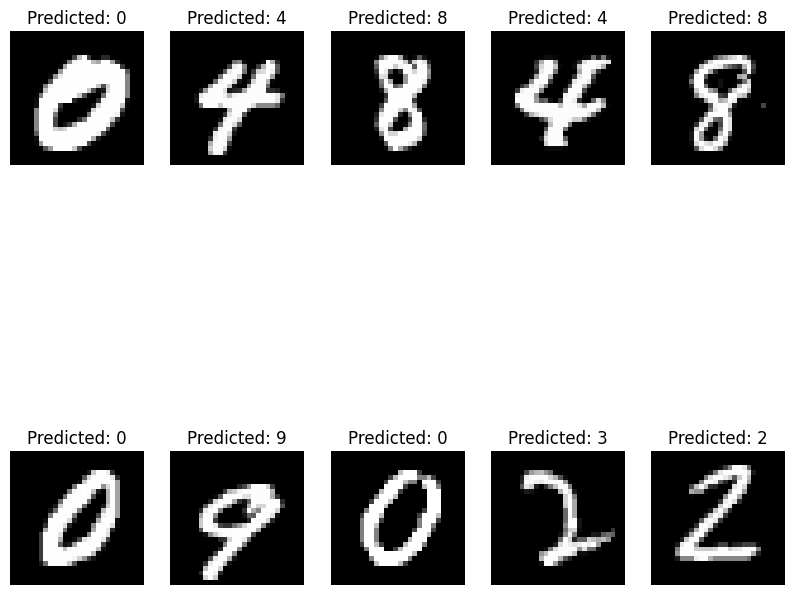

In [ ]:
import matplotlib.pyplot as plt
model.eval()
images, labels = next(iter(val_data))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

#Plot 10 test images with predictions
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Predicted: {predictions[i].item()}")
    plt.axis('off')
plt.show()